In [ ]:
####################################################################### 0a haar.

In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import random
import re

# ==============================
# Device Setup
# ==============================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
# Haar Cascade Face Detection
# ==============================
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        face = cv2.resize(face, (112, 112))
        return face
    else:
        return np.zeros((112, 112, 3), dtype=np.uint8)

# ==============================
# Dataset
# ==============================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.pairs = []
        self.transform = transform

        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match:
                continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                img0_path = os.path.join(root, im0)
                img1_path = os.path.join(root, im1)
                self.pairs.append((img0_path, img1_path, label))

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img0_path, img1_path, label = self.pairs[idx]
        img0 = cv2.imread(img0_path)
        img1 = cv2.imread(img1_path)
        img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img0 = detect_face_haar(img0)
        img1 = detect_face_haar(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# ==============================
# Transforms
# ==============================
transform = A.Compose([
    A.Resize(112, 112),
    A.Normalize(),
    ToTensorV2()
])

# ==============================
# Model
# ==============================
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        with torch.no_grad():
            dummy = self.backbone(torch.zeros(1, 3, 112, 112))
            self.flattened = dummy.view(1, -1).shape[1]
        self.fc = nn.Sequential(
            nn.Linear(self.flattened, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# ==============================
# Contrastive Loss
# ==============================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        dists = F.pairwise_distance(output1, output2, p=2)
        loss = label * dists.pow(2) + (1 - label) * F.relu(self.margin - dists).pow(2)
        return loss.mean()


# ==============================
# Train (clean only)
# ==============================
def train(model, loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}] Avg Loss: {total_loss / len(loader):.4f}")

# ==============================
# Evaluation: Clean
# ==============================
def evaluate(model, loader, threshold=0.7):
    model.eval()
    y_true, y_pred, sims = [], [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            pred = 1 if sim > threshold else 0
            y_true.append(int(label.item()))
            y_pred.append(pred)
            sims.append(sim)
    acc = accuracy_score(y_true, y_pred)
    try:
        roc_auc = roc_auc_score(y_true, sims)
    except:
        roc_auc = None
    print("\nEvaluation (Clean Data):")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}" if roc_auc else "ROC AUC: N/A")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


# ==============================
# Dataset, Model, Train, Evaluate
# ==============================
base_path = './AdvLFW/images' 
dataset = SiameseFaceDataset(base_path, transform=transform)

# Podział na trening/test 80/20
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

# Loadery
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Run Training and Evaluation
train(model, train_loader, criterion, optimizer, epochs=10)
evaluate(model, test_loader, threshold=0.819)


/Users/akaszynska/.local/share/virtualenvs/akaszynska-UBELCw3b/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/akaszynska/.local/share/virtualenvs/akaszynska-UBELCw3b/lib/python3.13/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Using device: mps


Epoch 1/10: 100%|█████████████████████████████| 600/600 [00:57<00:00, 10.45it/s]


Epoch [1/10] Avg Loss: 0.2458


Epoch 2/10: 100%|█████████████████████████████| 600/600 [00:57<00:00, 10.40it/s]


...

Epoch [8/10] Avg Loss: 0.0911


Epoch 9/10: 100%|█████████████████████████████| 600/600 [00:50<00:00, 11.82it/s]


Epoch [9/10] Avg Loss: 0.0665


Epoch 10/10: 100%|████████████████████████████| 600/600 [00:50<00:00, 11.92it/s]


Epoch [10/10] Avg Loss: 0.0454

Evaluation (Clean Data):
Accuracy: 0.7458
ROC AUC: 0.8323
Confusion Matrix:
 [[478 132]
 [173 417]]


In [ ]:
####################################################################### 0b haar.

In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import random
import re

# ==============================
# Device Setup
# ==============================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
# Haar Cascade Face Detection
# ==============================
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        face = cv2.resize(face, (112, 112))
        return face
    else:
        return np.zeros((112, 112, 3), dtype=np.uint8)

# ==============================
# Dataset
# ==============================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.pairs = []
        self.transform = transform

        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match:
                continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                img0_path = os.path.join(root, im0)
                img1_path = os.path.join(root, im1)
                self.pairs.append((img0_path, img1_path, label))

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img0_path, img1_path, label = self.pairs[idx]
        img0 = cv2.imread(img0_path)
        img1 = cv2.imread(img1_path)
        img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img0 = detect_face_haar(img0)
        img1 = detect_face_haar(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# ==============================
# Transforms
# ==============================
transform = A.Compose([
    A.Resize(112, 112),
    A.Normalize(),
    ToTensorV2()
])

# ==============================
# Model
# ==============================
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        with torch.no_grad():
            dummy = self.backbone(torch.zeros(1, 3, 112, 112))
            self.flattened = dummy.view(1, -1).shape[1]
        self.fc = nn.Sequential(
            nn.Linear(self.flattened, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# ==============================
# Contrastive Loss
# ==============================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        dists = F.pairwise_distance(output1, output2, p=2)
        loss = label * dists.pow(2) + (1 - label) * F.relu(self.margin - dists).pow(2)
        return loss.mean()


# ==============================
# Train (clean only)
# ==============================
def train(model, loader, criterion, optimizer, epochs=10, val_loader=None):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        print(f"Epoch [{epoch+1}/{epochs}] Avg Loss: {avg_loss:.4f}")

        if val_loader:
            print(f"Validation Metrics After Epoch {epoch+1}:")
            evaluate_loader_metrics(model, val_loader)

# ==============================
# Evaluation: Clean
# ==============================
from sklearn.metrics import f1_score

def evaluate_with_best_threshold(model, loader):
    model.eval()
    y_true, sims = [], []

    # Collect all true labels and cosine similarities
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    # Sweep through thresholds to find best
    best_threshold = 0.0
    best_accuracy = 0.0
    best_f1 = 0.0
    for threshold in np.arange(0.0, 1.01, 0.01):
        y_pred = [1 if s > threshold else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_accuracy:
            best_accuracy = acc
            best_threshold = threshold
            best_f1 = f1

    # Final evaluation with best threshold
    y_pred_final = [1 if s > best_threshold else 0 for s in sims]
    try:
        roc_auc = roc_auc_score(y_true, sims)
    except:
        roc_auc = None

    print("\nEvaluation with Best Threshold:")
    print(f"Best Threshold: {best_threshold:.2f}")
    print(f"Accuracy: {best_accuracy:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}" if roc_auc else "ROC AUC: N/A")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_final))


def evaluate_loader_metrics(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred, sims = [], [], []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))
            y_pred.append(1 if sim > threshold else 0)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    try:
        roc_auc = roc_auc_score(y_true, sims)
    except:
        roc_auc = None
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}" if roc_auc else "ROC AUC: N/A")
    print("Confusion Matrix:\n", cm)

    return acc, f1, roc_auc, cm


# ==============================
# Dataset, Model, Train, Evaluate
# ==============================
base_path = './AdvLFW/images' 
dataset = SiameseFaceDataset(base_path, transform=transform)

# Podział na trening/test 80/20
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

# Loadery
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Run Training and Evaluation
train(model, train_loader, criterion, optimizer, epochs=10, val_loader=test_loader)
evaluate_with_best_threshold(model, test_loader)


Using device: mps


Epoch 1/10: 100%|█████████████████████████████| 600/600 [00:57<00:00, 10.37it/s]


Epoch [1/10] Avg Loss: 0.2387


Epoch 2/10: 100%|█████████████████████████████| 600/600 [00:57<00:00, 10.50it/s]


Epoch [2/10] Avg Loss: 0.2103


...

Epoch [8/10] Avg Loss: 0.0925


Epoch 9/10: 100%|█████████████████████████████| 600/600 [00:58<00:00, 10.25it/s]


Epoch [9/10] Avg Loss: 0.0684


Epoch 10/10: 100%|████████████████████████████| 600/600 [00:58<00:00, 10.33it/s]


Epoch [10/10] Avg Loss: 0.0461

Evaluation with Best Threshold:
Best Threshold: 0.84
Accuracy: 0.7633
F1 Score: 0.7530
ROC AUC: 0.8379
Confusion Matrix:
 [[483 127]
 [157 433]]


In [ ]:
####################################################################### 1a haar + resnet => 61-66%

Using device: mps


/Users/akaszynska/Documents/01_studia/01_infProgramming/00_DSClub/01_DSC_adversarial/dataset/venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/akaszynska/Documents/01_studia/01_infProgramming/00_DSClub/01_DSC_adversarial/dataset/venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|█████████████████████████████| 600/600 [00:53<00:00, 11.24it/s]


[Epoch 1] Loss: 0.2849

Validation Results:
Best Threshold: 0.85
Accuracy: 0.5567
F1 Score: 0.6048
ROC AUC: 0.5659
Confusion Matrix:
 [[261 349]
 [183 407]]


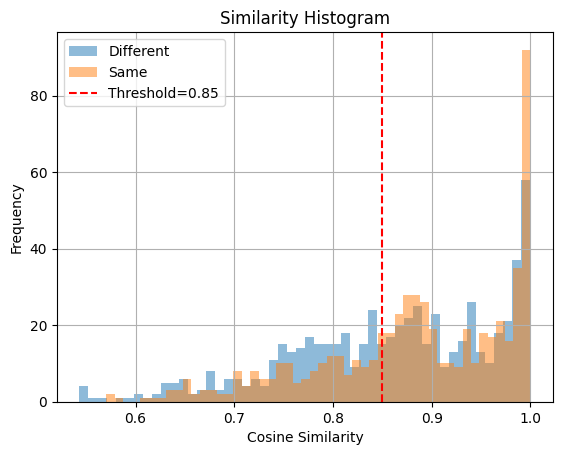

Epoch 2/10: 100%|█████████████████████████████| 600/600 [00:49<00:00, 12.12it/s]


[Epoch 2] Loss: 0.3114

Validation Results:
Best Threshold: 0.90
Accuracy: 0.5958
F1 Score: 0.5865
ROC AUC: 0.6254
Confusion Matrix:
 [[371 239]
 [246 344]]


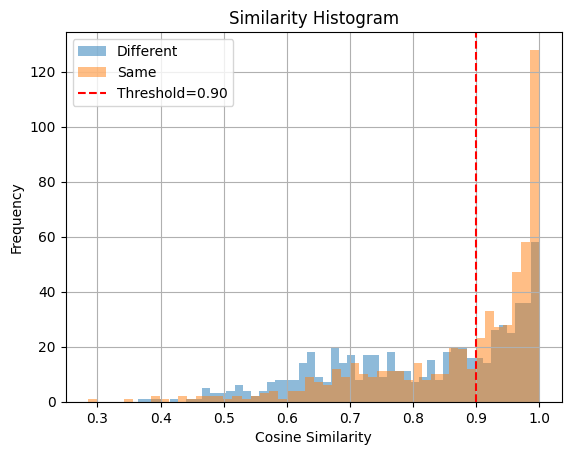

Epoch 3/10: 100%|█████████████████████████████| 600/600 [00:49<00:00, 12.07it/s]


[Epoch 3] Loss: 0.2563

Validation Results:
Best Threshold: 0.95
Accuracy: 0.5950
F1 Score: 0.5354
ROC AUC: 0.6233
Confusion Matrix:
 [[434 176]
 [310 280]]


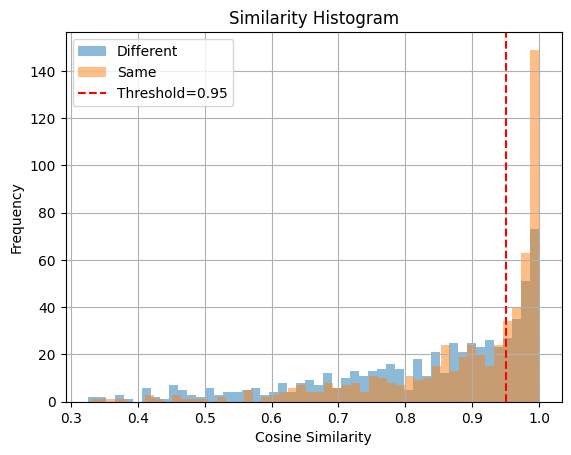

Epoch 4/10: 100%|█████████████████████████████| 600/600 [00:50<00:00, 11.98it/s]


[Epoch 4] Loss: 0.2495

Validation Results:
Best Threshold: 0.91
Accuracy: 0.5958
F1 Score: 0.6543
ROC AUC: 0.6241
Confusion Matrix:
 [[256 354]
 [131 459]]


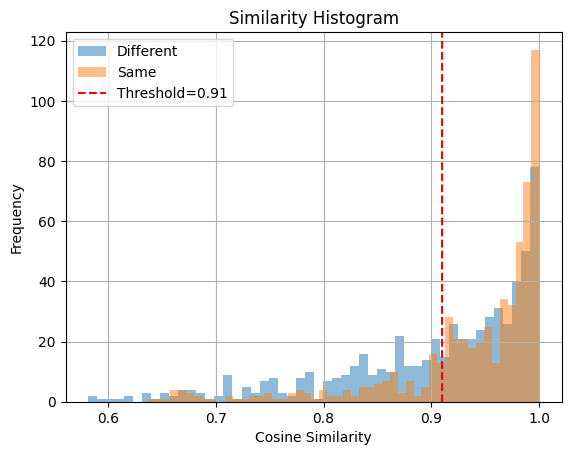

Epoch 5/10: 100%|█████████████████████████████| 600/600 [00:50<00:00, 11.96it/s]


[Epoch 5] Loss: 0.2461

Validation Results:
Best Threshold: 0.87
Accuracy: 0.6108
F1 Score: 0.6320
ROC AUC: 0.6471
Confusion Matrix:
 [[332 278]
 [189 401]]


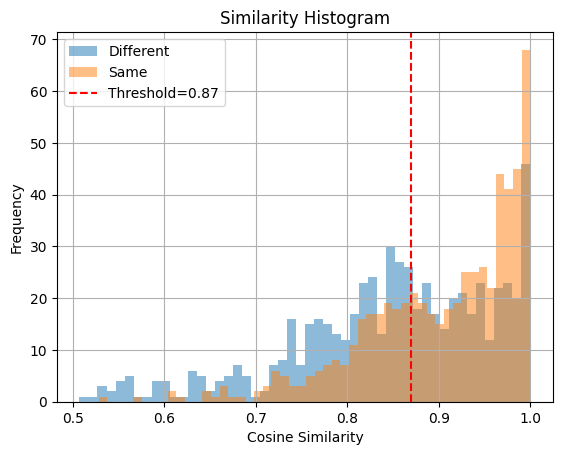

Epoch 6/10: 100%|█████████████████████████████| 600/600 [00:49<00:00, 12.07it/s]


[Epoch 6] Loss: 0.2371

Validation Results:
Best Threshold: 0.90
Accuracy: 0.6350
F1 Score: 0.6117
ROC AUC: 0.6722
Confusion Matrix:
 [[417 193]
 [245 345]]


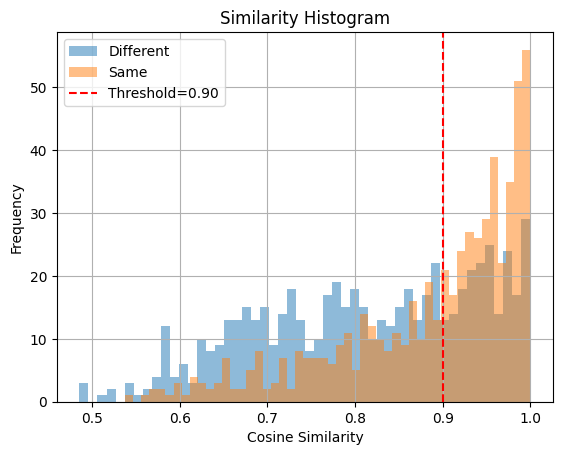

Epoch 7/10: 100%|█████████████████████████████| 600/600 [00:49<00:00, 12.18it/s]


[Epoch 7] Loss: 0.2309

Validation Results:
Best Threshold: 0.88
Accuracy: 0.6292
F1 Score: 0.6147
ROC AUC: 0.6703
Confusion Matrix:
 [[400 210]
 [235 355]]


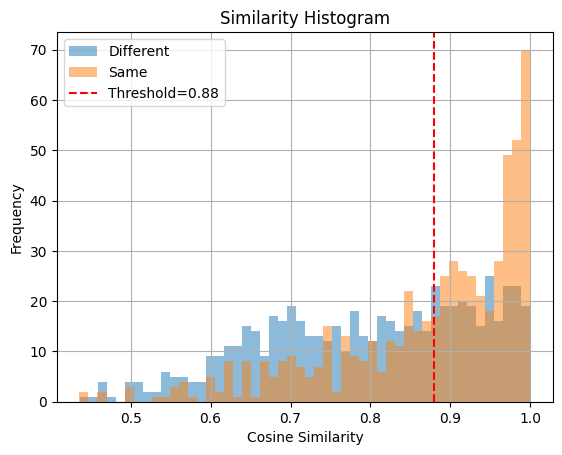

Epoch 8/10: 100%|█████████████████████████████| 600/600 [00:49<00:00, 12.03it/s]


[Epoch 8] Loss: 0.2274

Validation Results:
Best Threshold: 0.88
Accuracy: 0.6292
F1 Score: 0.6647
ROC AUC: 0.6747
Confusion Matrix:
 [[314 296]
 [149 441]]


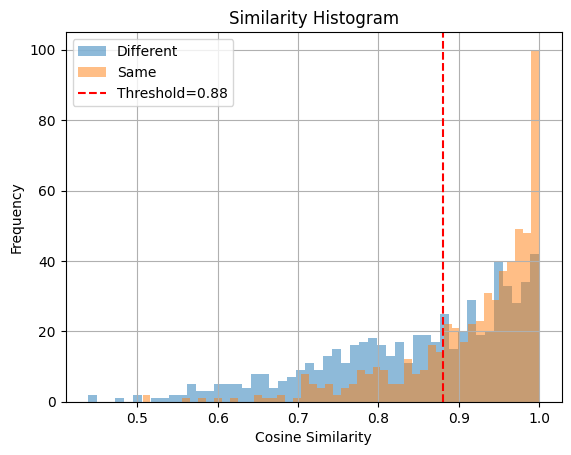

Epoch 9/10: 100%|█████████████████████████████| 600/600 [00:48<00:00, 12.25it/s]


[Epoch 9] Loss: 0.2247

Validation Results:
Best Threshold: 0.89
Accuracy: 0.6650
F1 Score: 0.6442
ROC AUC: 0.7067
Confusion Matrix:
 [[434 176]
 [226 364]]


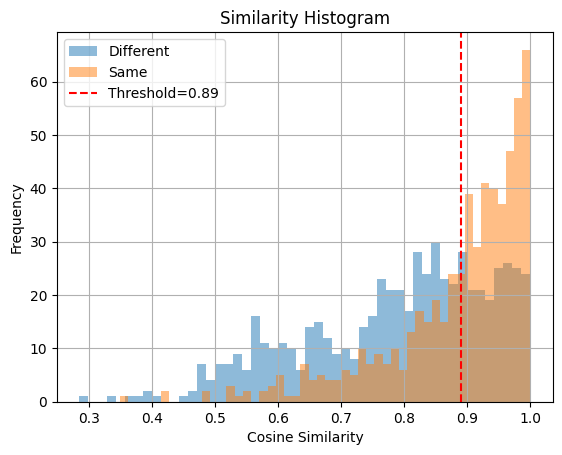

Epoch 10/10: 100%|████████████████████████████| 600/600 [00:50<00:00, 11.87it/s]


[Epoch 10] Loss: 0.2225

Validation Results:
Best Threshold: 0.94
Accuracy: 0.6175
F1 Score: 0.5565
ROC AUC: 0.6523
Confusion Matrix:
 [[453 157]
 [302 288]]


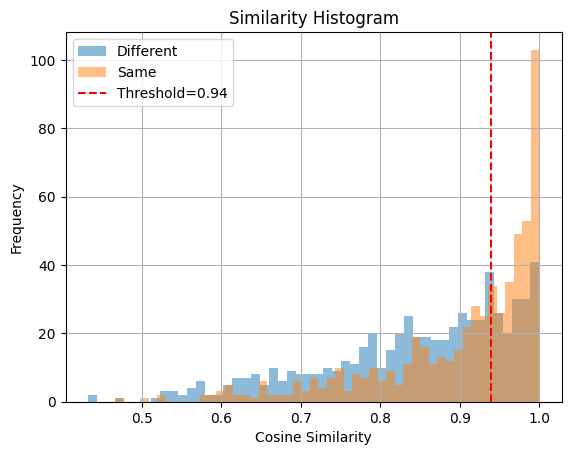

In [1]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Haar Cascade for Face Detection
# =========================
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.pairs = []
        self.transform = transform
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = detect_face_haar(img0)
        img1 = detect_face_haar(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='resnet'):
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Validation
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[Epoch {epoch+1}] Loss: {total_loss / len(train_loader):.4f}")
        evaluate_with_histogram(model, val_loader)

# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'
    dataset = SiameseFaceDataset(base_path, transform=transform)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    model = SiameseNetwork(backbone='resnet').to(device)  # 'mobilenet' or 'facenet'
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train(model, train_loader, val_loader, criterion, optimizer, epochs=10)


In [ ]:
################################################ 2 haar + facenet => 56% [4 epoki] - bez droput

Using device: mps


Epoch 1/20: 100%|███████████████████████████| 600/600 [1:29:08<00:00,  8.91s/it]


[Epoch 1] Train Loss: 0.2572

Validation Results:
Best Threshold: 0.90
Accuracy: 0.5392
F1 Score: 0.6081
ROC AUC: 0.5466
Confusion Matrix:
 [[218 392]
 [161 429]]


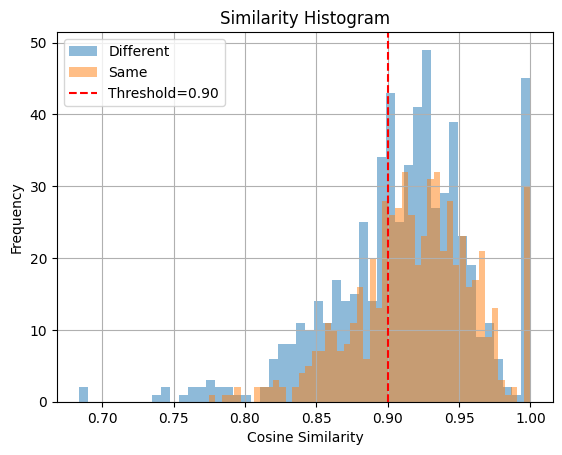

[Epoch 1] Validation Loss: 0.2764
Validation loss improved. Saving model...


Epoch 2/20: 100%|███████████████████████████| 600/600 [1:48:24<00:00, 10.84s/it]


[Epoch 2] Train Loss: 0.2489

Validation Results:
Best Threshold: 0.95
Accuracy: 0.5350
F1 Score: 0.5747
ROC AUC: 0.5334
Confusion Matrix:
 [[265 345]
 [213 377]]


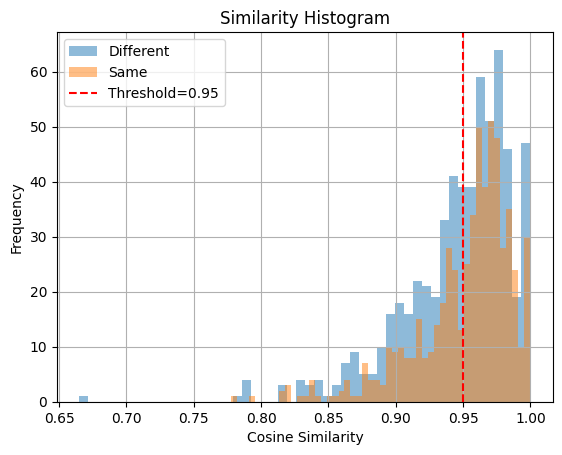

[Epoch 2] Validation Loss: 0.3073
No improvement for 1 epoch(s).


Epoch 3/20: 100%|███████████████████████████| 600/600 [2:48:28<00:00, 16.85s/it]


[Epoch 3] Train Loss: 0.2455

Validation Results:
Best Threshold: 0.89
Accuracy: 0.5542
F1 Score: 0.6022
ROC AUC: 0.5771
Confusion Matrix:
 [[260 350]
 [185 405]]


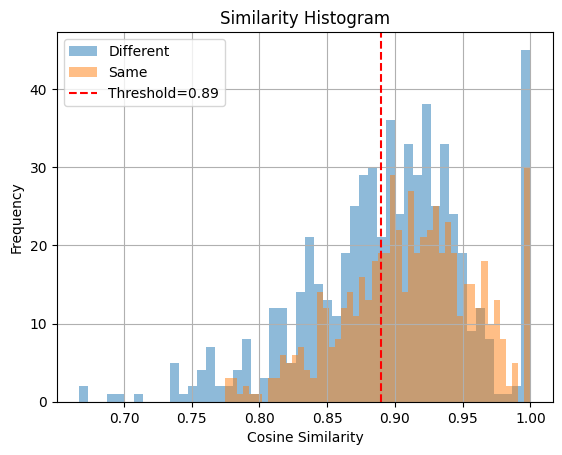

[Epoch 3] Validation Loss: 0.2661
Validation loss improved. Saving model...


Epoch 4/20: 100%|███████████████████████████| 600/600 [4:15:50<00:00, 25.58s/it]


[Epoch 4] Train Loss: 0.2447

Validation Results:
Best Threshold: 0.86
Accuracy: 0.5675
F1 Score: 0.6462
ROC AUC: 0.5977
Confusion Matrix:
 [[207 403]
 [116 474]]


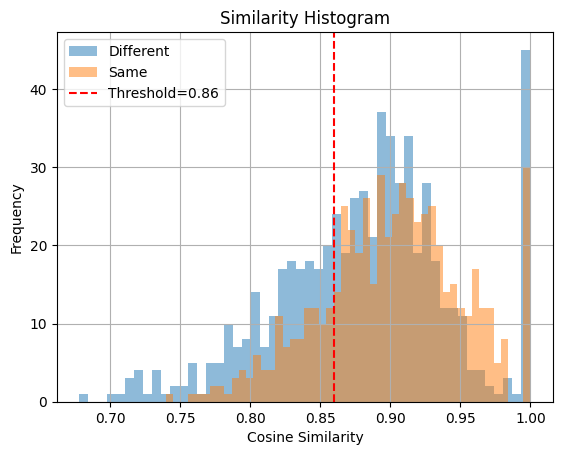

[Epoch 4] Validation Loss: 0.2602
Validation loss improved. Saving model...


Epoch 5/20:  41%|██████████▎              | 248/600 [1:41:34<2:24:09, 24.57s/it]


KeyboardInterrupt: 

In [1]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Detektory twarzy
try:
    from facenet_pytorch import MTCNN
    mtcnn_detector = MTCNN(keep_all=True, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
except ImportError:
    mtcnn_detector = None
try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Face detection methods
# =========================

# Haar Cascade
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# MTCNN
def detect_face_mtcnn(image):
    if mtcnn_detector is None:
        raise RuntimeError("facenet-pytorch is not installed!")
    boxes, _ = mtcnn_detector.detect(image)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0].astype(int)
        face = image[y1:y2, x1:x2]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# RetinaFace
def detect_face_retinaface(image):
    if RetinaFace is None:
        raise RuntimeError("retinaface package is not installed!")
    faces = RetinaFace.extract_faces(image, align=True)
    if faces and len(faces) > 0:
        face = faces[0]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class with detector selection
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, detector='haar'):
        self.pairs = []
        self.transform = transform
        self.detector = detector
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def detect(self, image):
        if self.detector == 'haar':
            return detect_face_haar(image)
        elif self.detector == 'mtcnn':
            return detect_face_mtcnn(image)
        elif self.detector == 'retinaface':
            return detect_face_retinaface(image)
        else:
            raise ValueError(f"Unknown detector: {self.detector}")

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = self.detect(img0)
        img1 = self.detect(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='resnet'):
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            # nn.Dropout(dropout_prob), // zapomniałam w tej wersji 
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        if hasattr(self.feature_extractor, 'eval'):
            # facenet (eval mode)
            with torch.no_grad():
                x = self.feature_extractor(x)
        else:
            x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Early Stopping
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=3, min_delta=1e-4):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f}")

        # Ewaluacja na zbiorze walidacyjnym (wyświetla histogram i metryki)
        evaluate_with_histogram(model, val_loader)

        # early stopping
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                out1, out2 = model(img1, img2)
                val_loss = criterion(out1, out2, label)
                val_loss_total += val_loss.item()
        avg_val_loss = val_loss_total / len(val_loader)
        print(f"[Epoch {epoch+1}] Validation Loss: {avg_val_loss:.4f}")

        # Sprawdzenie early stopping
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print("Validation loss improved. Saving model...")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping activated after {epoch+1} epochs.")
            break

    # Załaduj najlepszy model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'
    # Wybierz detektor: 'haar', 'mtcnn', 'retinaface'
    chosen_detector = 'retinaface'
    dataset = SiameseFaceDataset(base_path, transform=transform, detector=chosen_detector)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    # backbone: 'resnet', 'mobilenet', 'facenet'
    model = SiameseNetwork(backbone='facenet').to(device)
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5)


In [ ]:
################################################ 2 retinaface + resnet
################################################ + contrastive loss + cosine sim + regularisation + early stopping
################################################ => 

Using device: mps


Epoch 1/20: 100%|███████████████████████████| 600/600 [1:29:44<00:00,  8.97s/it]


[Epoch 1] Train Loss: 0.2605

Validation Results:
Best Threshold: 0.94
Accuracy: 0.5092
F1 Score: 0.6445
ROC AUC: 0.5117
Confusion Matrix:
 [[ 77 533]
 [ 56 534]]


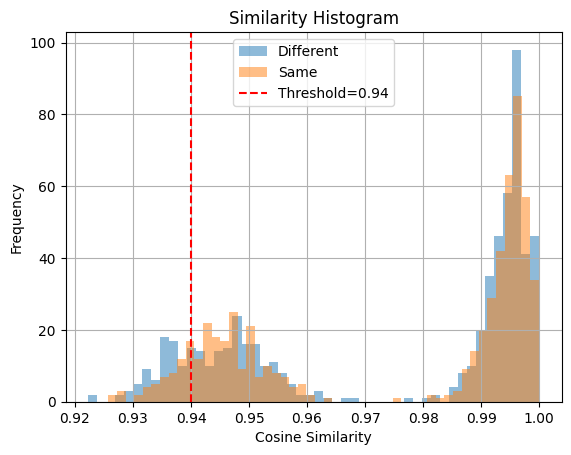

[Epoch 1] Validation Loss: 0.3672
Validation loss improved. Saving model...


Epoch 2/20: 100%|███████████████████████████| 600/600 [2:08:27<00:00, 12.85s/it]


[Epoch 2] Train Loss: 0.2581

Validation Results:
Best Threshold: 1.00
Accuracy: 0.5083
F1 Score: 0.0000
ROC AUC: 0.5104
Confusion Matrix:
 [[610   0]
 [590   0]]


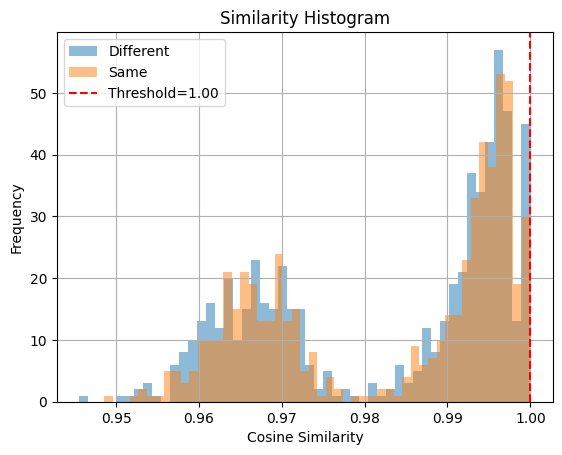

[Epoch 2] Validation Loss: 0.3779
No improvement for 1 epoch(s).


Epoch 3/20: 100%|███████████████████████████| 600/600 [2:23:58<00:00, 14.40s/it]


[Epoch 3] Train Loss: 0.2548

Validation Results:
Best Threshold: 1.00
Accuracy: 0.5083
F1 Score: 0.0000
ROC AUC: 0.5028
Confusion Matrix:
 [[610   0]
 [590   0]]


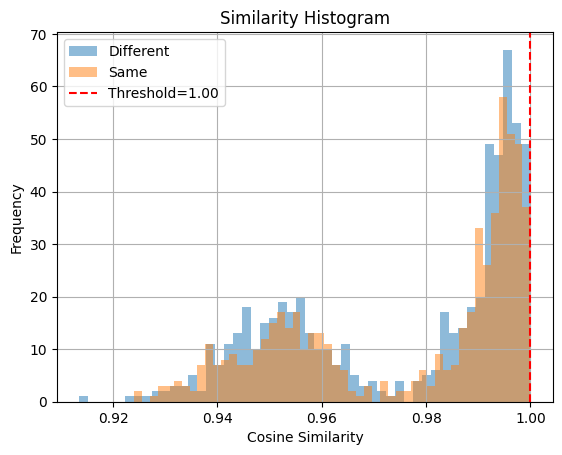

KeyboardInterrupt: 

In [3]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Detektory twarzy
try:
    from facenet_pytorch import MTCNN
    mtcnn_detector = MTCNN(keep_all=True, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
except ImportError:
    mtcnn_detector = None
try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Face detection methods
# =========================

# Haar Cascade
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# MTCNN
def detect_face_mtcnn(image):
    if mtcnn_detector is None:
        raise RuntimeError("facenet-pytorch is not installed!")
    boxes, _ = mtcnn_detector.detect(image)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0].astype(int)
        face = image[y1:y2, x1:x2]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# RetinaFace
def detect_face_retinaface(image):
    if RetinaFace is None:
        raise RuntimeError("retinaface package is not installed!")
    faces = RetinaFace.extract_faces(image, align=True)
    if faces and len(faces) > 0:
        face = faces[0]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class with detector selection
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, detector='retinaface'):
        self.pairs = []
        self.transform = transform
        self.detector = detector
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def detect(self, image):
        if self.detector == 'haar':
            return detect_face_haar(image)
        elif self.detector == 'mtcnn':
            return detect_face_mtcnn(image)
        elif self.detector == 'retinaface':
            return detect_face_retinaface(image)
        else:
            raise ValueError(f"Unknown detector: {self.detector}")

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = self.detect(img0)
        img1 = self.detect(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='resnet', dropout_prob=0.3):  
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),  
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        if hasattr(self.feature_extractor, 'eval'):
            # used in eval mode
            with torch.no_grad():
                x = self.feature_extractor(x)
        else:
            x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Early Stopping
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=3, min_delta=1e-4):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f}")

        # Ewaluacja na zbiorze walidacyjnym (wyświetla histogram i metryki)
        evaluate_with_histogram(model, val_loader)

        # early stopping
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                out1, out2 = model(img1, img2)
                val_loss = criterion(out1, out2, label)
                val_loss_total += val_loss.item()
        avg_val_loss = val_loss_total / len(val_loader)
        print(f"[Epoch {epoch+1}] Validation Loss: {avg_val_loss:.4f}")

        # Sprawdzenie early stopping
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print("Validation loss improved. Saving model...")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping activated after {epoch+1} epochs.")
            break

    # najlepszy model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'

    # Wybierz detektor: 'haar', 'mtcnn', 'retinaface'
    chosen_detector = 'retinaface'

    # Przygotowanie datasetu
    dataset = SiameseFaceDataset(base_path, transform=transform, detector=chosen_detector)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    # backbone: 'resnet', 'mobilenet', 'facenet'
    model = SiameseNetwork(backbone='resnet', dropout_prob=0.3).to(device)

    # Kryterium i optymalizator
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Trening z early stopping
    train(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5)



In [ ]:
################################################ 3 haar + resnet
################################################ + contrastive loss + cosine sim + regularisation + early stopping
################################################ => 64

Using device: mps


Epoch 1/20: 100%|█████████████████████████████| 600/600 [00:27<00:00, 21.73it/s]


[Epoch 1] Train Loss: 0.2599

Validation Results:
Best Threshold: 0.99
Accuracy: 0.5150
F1 Score: 0.6335
ROC AUC: 0.5877
Confusion Matrix:
 [[115 495]
 [ 87 503]]


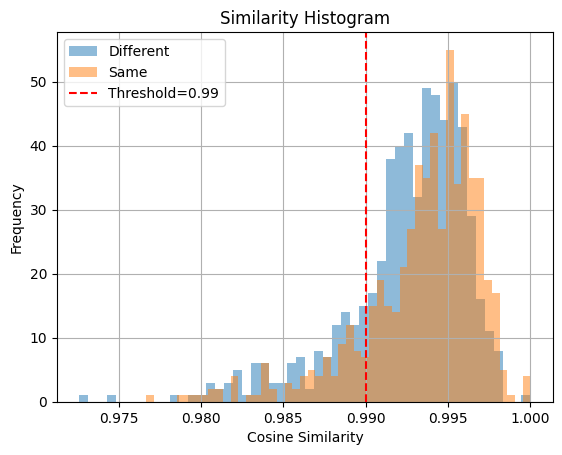

[Epoch 1] Validation Loss: 0.4013
Validation loss improved. Saving model...


Epoch 2/20: 100%|█████████████████████████████| 600/600 [00:32<00:00, 18.63it/s]


[Epoch 2] Train Loss: 0.2574

Validation Results:
Best Threshold: 0.99
Accuracy: 0.5750
F1 Score: 0.4990
ROC AUC: 0.6047
Confusion Matrix:
 [[436 174]
 [336 254]]


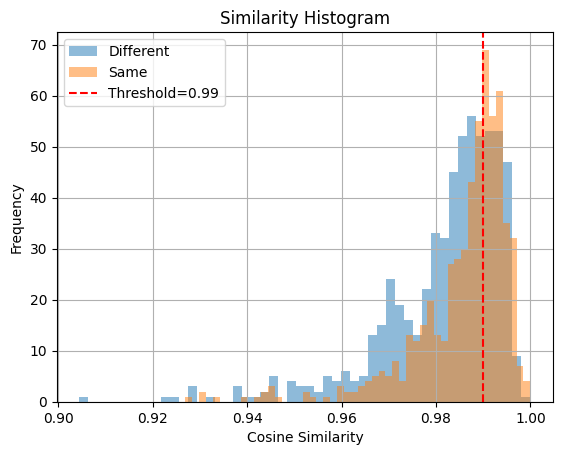

[Epoch 2] Validation Loss: 0.3572
Validation loss improved. Saving model...


Epoch 3/20: 100%|█████████████████████████████| 600/600 [00:32<00:00, 18.36it/s]


[Epoch 3] Train Loss: 0.2512

Validation Results:
Best Threshold: 0.97
Accuracy: 0.5983
F1 Score: 0.5922
ROC AUC: 0.6190
Confusion Matrix:
 [[368 242]
 [240 350]]


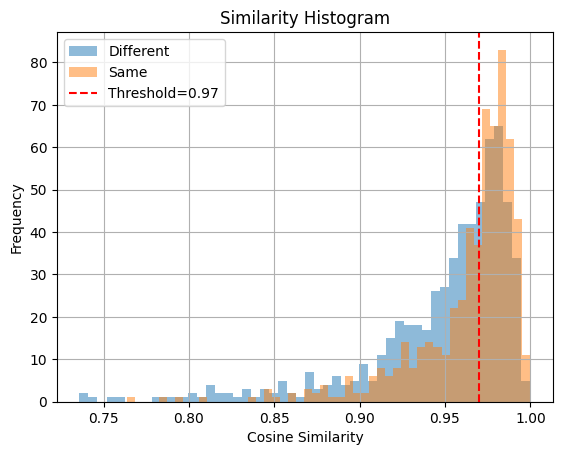

[Epoch 3] Validation Loss: 0.2953
Validation loss improved. Saving model...


Epoch 4/20: 100%|█████████████████████████████| 600/600 [00:32<00:00, 18.49it/s]


[Epoch 4] Train Loss: 0.2482

Validation Results:
Best Threshold: 0.96
Accuracy: 0.5800
F1 Score: 0.6426
ROC AUC: 0.6160
Confusion Matrix:
 [[243 367]
 [137 453]]


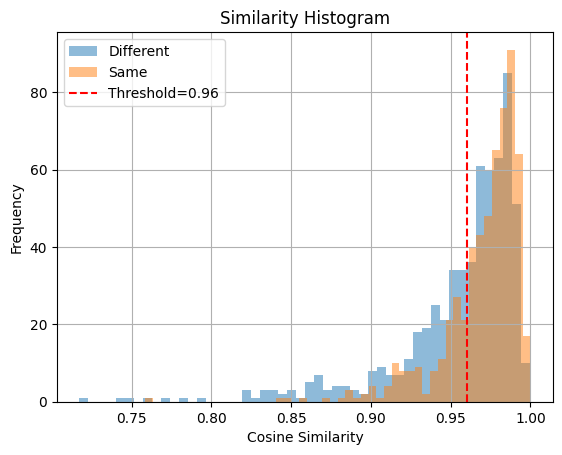

[Epoch 4] Validation Loss: 0.3039
No improvement for 1 epoch(s).


Epoch 5/20: 100%|█████████████████████████████| 600/600 [00:33<00:00, 18.09it/s]


[Epoch 5] Train Loss: 0.2439

Validation Results:
Best Threshold: 0.92
Accuracy: 0.6075
F1 Score: 0.6509
ROC AUC: 0.6540
Confusion Matrix:
 [[290 320]
 [151 439]]


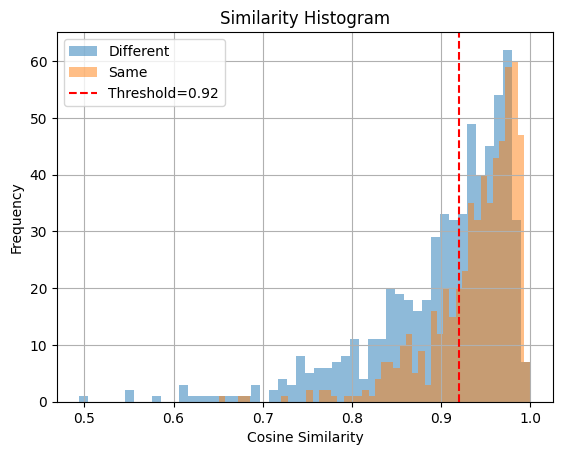

[Epoch 5] Validation Loss: 0.2502
Validation loss improved. Saving model...


Epoch 6/20: 100%|█████████████████████████████| 600/600 [00:30<00:00, 19.91it/s]


[Epoch 6] Train Loss: 0.2371

Validation Results:
Best Threshold: 0.96
Accuracy: 0.5883
F1 Score: 0.5566
ROC AUC: 0.6316
Confusion Matrix:
 [[396 214]
 [280 310]]


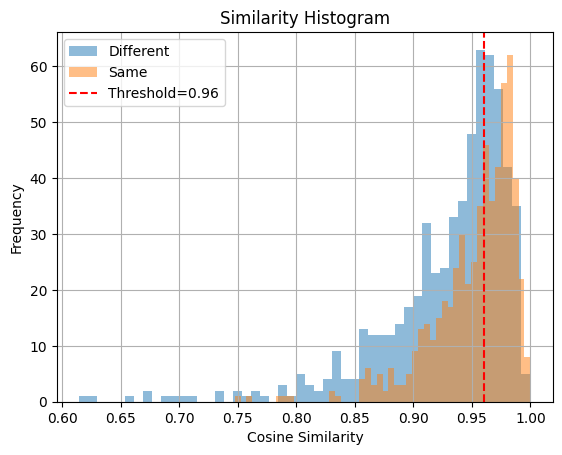

[Epoch 6] Validation Loss: 0.2704
No improvement for 1 epoch(s).


Epoch 7/20: 100%|█████████████████████████████| 600/600 [00:32<00:00, 18.36it/s]


[Epoch 7] Train Loss: 0.2313

Validation Results:
Best Threshold: 0.92
Accuracy: 0.6075
F1 Score: 0.6424
ROC AUC: 0.6514
Confusion Matrix:
 [[306 304]
 [167 423]]


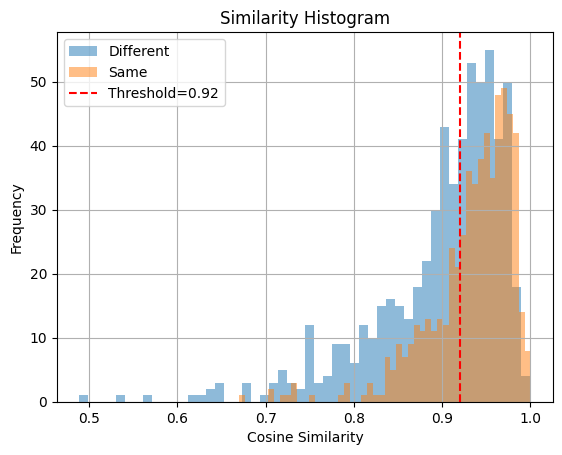

[Epoch 7] Validation Loss: 0.2468
Validation loss improved. Saving model...


Epoch 8/20: 100%|█████████████████████████████| 600/600 [00:32<00:00, 18.56it/s]


[Epoch 8] Train Loss: 0.2264

Validation Results:
Best Threshold: 0.93
Accuracy: 0.6233
F1 Score: 0.6586
ROC AUC: 0.6561
Confusion Matrix:
 [[312 298]
 [154 436]]


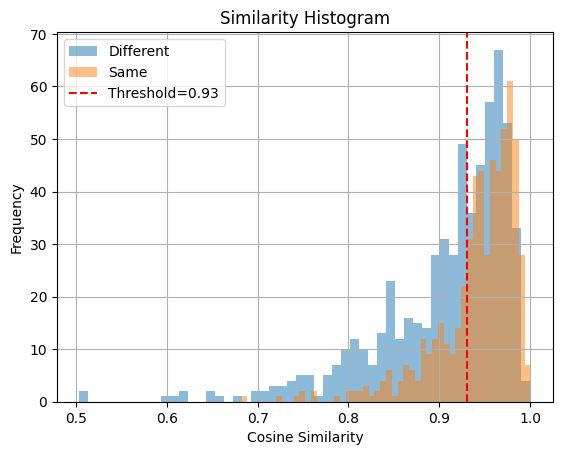

[Epoch 8] Validation Loss: 0.2518
No improvement for 1 epoch(s).


Epoch 9/20: 100%|█████████████████████████████| 600/600 [00:33<00:00, 17.67it/s]


[Epoch 9] Train Loss: 0.2216

Validation Results:
Best Threshold: 0.85
Accuracy: 0.6167
F1 Score: 0.6652
ROC AUC: 0.6682
Confusion Matrix:
 [[283 327]
 [133 457]]


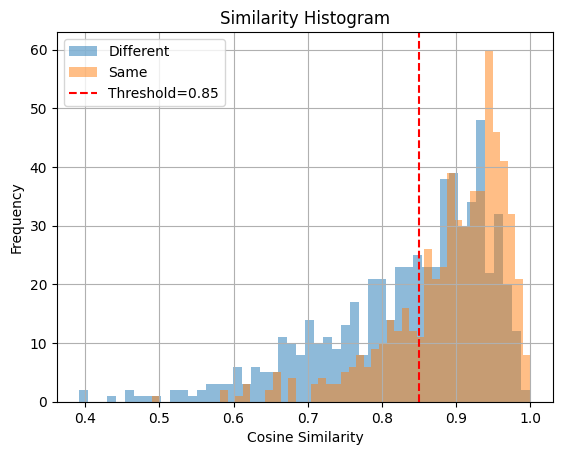

[Epoch 9] Validation Loss: 0.2292
Validation loss improved. Saving model...


Epoch 10/20: 100%|████████████████████████████| 600/600 [00:32<00:00, 18.46it/s]


[Epoch 10] Train Loss: 0.2234

Validation Results:
Best Threshold: 0.91
Accuracy: 0.6267
F1 Score: 0.6427
ROC AUC: 0.6673
Confusion Matrix:
 [[349 261]
 [187 403]]


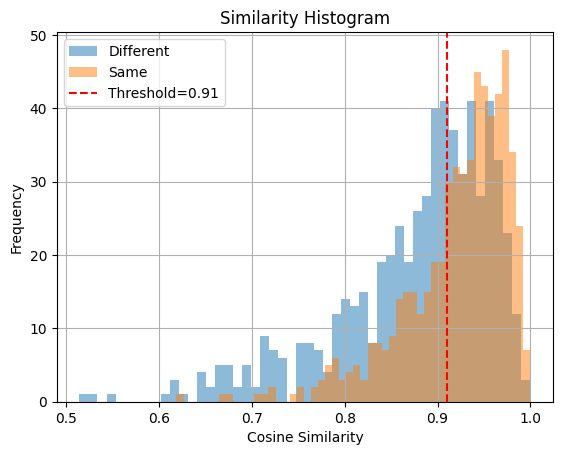

[Epoch 10] Validation Loss: 0.2357
No improvement for 1 epoch(s).


Epoch 11/20: 100%|████████████████████████████| 600/600 [00:31<00:00, 18.75it/s]


[Epoch 11] Train Loss: 0.2208

Validation Results:
Best Threshold: 0.90
Accuracy: 0.6217
F1 Score: 0.6508
ROC AUC: 0.6705
Confusion Matrix:
 [[323 287]
 [167 423]]


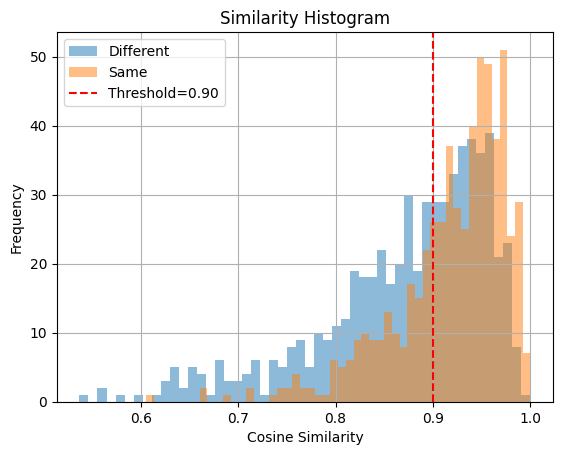

[Epoch 11] Validation Loss: 0.2332
No improvement for 2 epoch(s).


Epoch 12/20: 100%|████████████████████████████| 600/600 [00:32<00:00, 18.28it/s]


[Epoch 12] Train Loss: 0.2192

Validation Results:
Best Threshold: 0.88
Accuracy: 0.6267
F1 Score: 0.6739
ROC AUC: 0.6757
Confusion Matrix:
 [[289 321]
 [127 463]]


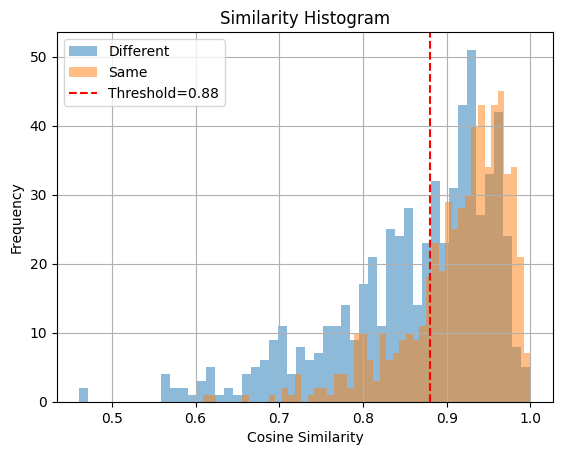

[Epoch 12] Validation Loss: 0.2294
No improvement for 3 epoch(s).


Epoch 13/20: 100%|████████████████████████████| 600/600 [00:31<00:00, 18.78it/s]


[Epoch 13] Train Loss: 0.2163

Validation Results:
Best Threshold: 0.87
Accuracy: 0.6283
F1 Score: 0.6499
ROC AUC: 0.6764
Confusion Matrix:
 [[340 270]
 [176 414]]


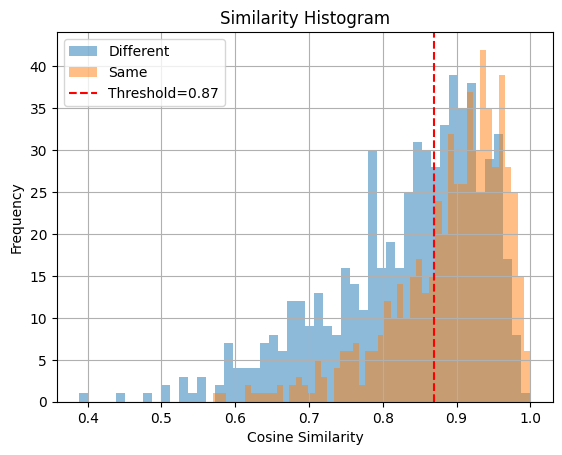

[Epoch 13] Validation Loss: 0.2262
Validation loss improved. Saving model...


Epoch 14/20: 100%|████████████████████████████| 600/600 [00:31<00:00, 18.77it/s]


[Epoch 14] Train Loss: 0.2159

Validation Results:
Best Threshold: 0.86
Accuracy: 0.6367
F1 Score: 0.6572
ROC AUC: 0.6848
Confusion Matrix:
 [[346 264]
 [172 418]]


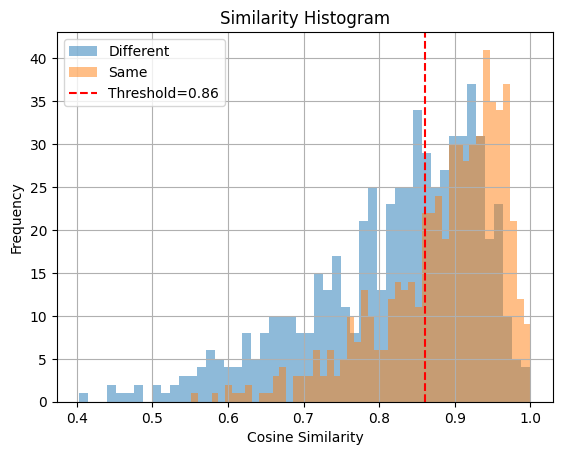

[Epoch 14] Validation Loss: 0.2241
Validation loss improved. Saving model...


Epoch 15/20: 100%|████████████████████████████| 600/600 [00:31<00:00, 18.96it/s]


[Epoch 15] Train Loss: 0.2116

Validation Results:
Best Threshold: 0.90
Accuracy: 0.6433
F1 Score: 0.6272
ROC AUC: 0.6935
Confusion Matrix:
 [[412 198]
 [230 360]]


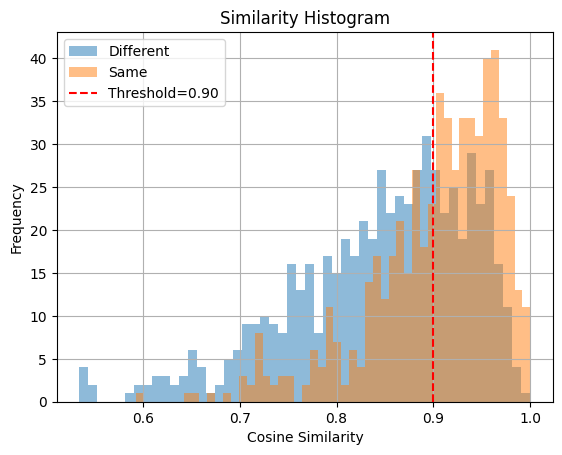

[Epoch 15] Validation Loss: 0.2226
Validation loss improved. Saving model...


Epoch 16/20: 100%|████████████████████████████| 600/600 [00:32<00:00, 18.39it/s]


[Epoch 16] Train Loss: 0.2097

Validation Results:
Best Threshold: 0.90
Accuracy: 0.6383
F1 Score: 0.6383
ROC AUC: 0.6846
Confusion Matrix:
 [[383 227]
 [207 383]]


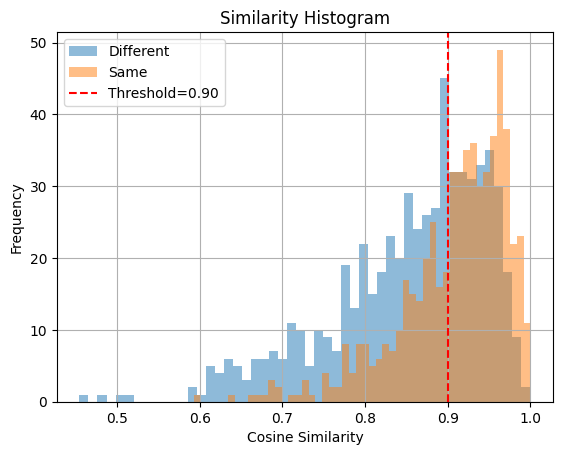

[Epoch 16] Validation Loss: 0.2254
No improvement for 1 epoch(s).


Epoch 17/20: 100%|████████████████████████████| 600/600 [00:32<00:00, 18.45it/s]


[Epoch 17] Train Loss: 0.2094

Validation Results:
Best Threshold: 0.92
Accuracy: 0.6342
F1 Score: 0.6295
ROC AUC: 0.6776
Confusion Matrix:
 [[388 222]
 [217 373]]


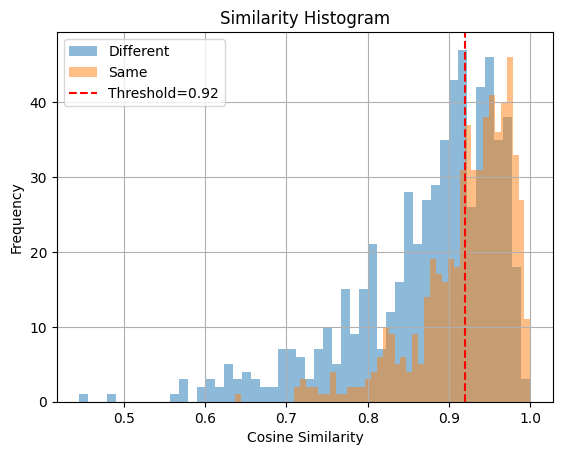

[Epoch 17] Validation Loss: 0.2324
No improvement for 2 epoch(s).


Epoch 18/20: 100%|████████████████████████████| 600/600 [00:33<00:00, 18.02it/s]


[Epoch 18] Train Loss: 0.2085

Validation Results:
Best Threshold: 0.87
Accuracy: 0.6325
F1 Score: 0.6667
ROC AUC: 0.6921
Confusion Matrix:
 [[318 292]
 [149 441]]


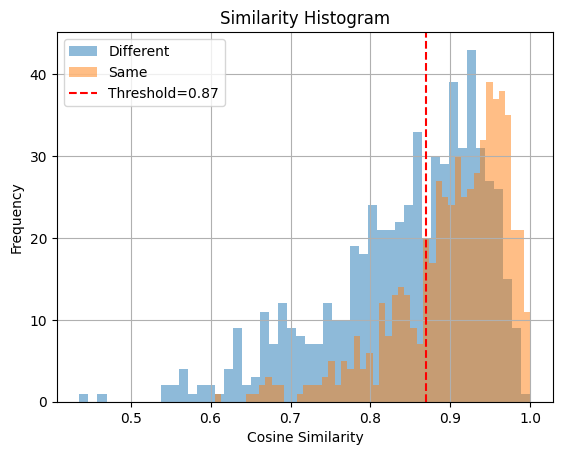

[Epoch 18] Validation Loss: 0.2223
Validation loss improved. Saving model...


Epoch 19/20: 100%|████████████████████████████| 600/600 [00:30<00:00, 19.40it/s]


[Epoch 19] Train Loss: 0.2028

Validation Results:
Best Threshold: 0.88
Accuracy: 0.6325
F1 Score: 0.6682
ROC AUC: 0.6853
Confusion Matrix:
 [[315 295]
 [146 444]]


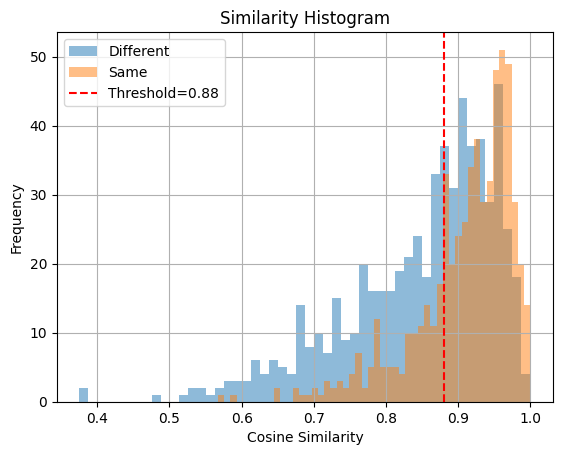

[Epoch 19] Validation Loss: 0.2255
No improvement for 1 epoch(s).


Epoch 20/20: 100%|████████████████████████████| 600/600 [00:33<00:00, 17.96it/s]


[Epoch 20] Train Loss: 0.2018

Validation Results:
Best Threshold: 0.87
Accuracy: 0.6450
F1 Score: 0.6840
ROC AUC: 0.6926
Confusion Matrix:
 [[313 297]
 [129 461]]


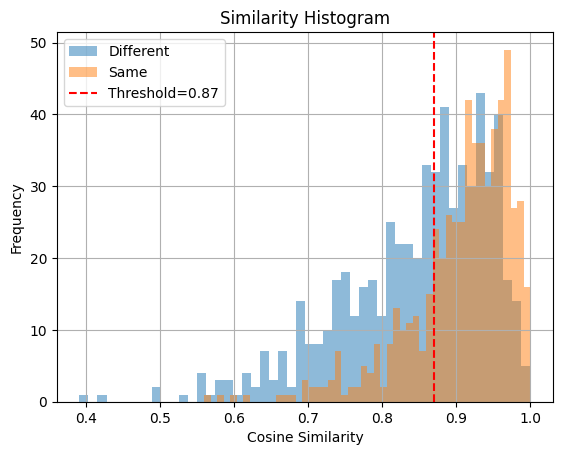

[Epoch 20] Validation Loss: 0.2233
No improvement for 2 epoch(s).


In [4]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Detektory twarzy
try:
    from facenet_pytorch import MTCNN
    mtcnn_detector = MTCNN(keep_all=True, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
except ImportError:
    mtcnn_detector = None
try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Face detection methods
# =========================

# Haar Cascade
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# MTCNN
def detect_face_mtcnn(image):
    if mtcnn_detector is None:
        raise RuntimeError("facenet-pytorch is not installed!")
    boxes, _ = mtcnn_detector.detect(image)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0].astype(int)
        face = image[y1:y2, x1:x2]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# RetinaFace
def detect_face_retinaface(image):
    if RetinaFace is None:
        raise RuntimeError("retinaface package is not installed!")
    faces = RetinaFace.extract_faces(image, align=True)
    if faces and len(faces) > 0:
        face = faces[0]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class with detector selection
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, detector='haar'):
        self.pairs = []
        self.transform = transform
        self.detector = detector
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def detect(self, image):
        if self.detector == 'haar':
            return detect_face_haar(image)
        elif self.detector == 'mtcnn':
            return detect_face_mtcnn(image)
        elif self.detector == 'retinaface':
            return detect_face_retinaface(image)
        else:
            raise ValueError(f"Unknown detector: {self.detector}")

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = self.detect(img0)
        img1 = self.detect(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='resnet', dropout_prob=0.3):  
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),  
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        if hasattr(self.feature_extractor, 'eval'):
            # used in eval mode
            with torch.no_grad():
                x = self.feature_extractor(x)
        else:
            x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Early Stopping
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=3, min_delta=1e-4):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f}")

        # Ewaluacja na zbiorze walidacyjnym (wyświetla histogram i metryki)
        evaluate_with_histogram(model, val_loader)

        # early stopping
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                out1, out2 = model(img1, img2)
                val_loss = criterion(out1, out2, label)
                val_loss_total += val_loss.item()
        avg_val_loss = val_loss_total / len(val_loader)
        print(f"[Epoch {epoch+1}] Validation Loss: {avg_val_loss:.4f}")

        # Sprawdzenie early stopping
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print("Validation loss improved. Saving model...")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping activated after {epoch+1} epochs.")
            break

    # najlepszy model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'

    # Wybierz detektor: 'haar', 'mtcnn', 'retinaface'
    chosen_detector = 'haar'

    # Przygotowanie datasetu
    dataset = SiameseFaceDataset(base_path, transform=transform, detector=chosen_detector)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    # backbone: 'resnet', 'mobilenet', 'facenet'
    model = SiameseNetwork(backbone='resnet', dropout_prob=0.3).to(device)

    # Kryterium i optymalizator
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Trening z early stopping
    train(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5)



In [ ]:
################################################ 3 haar + facenet
################################################ + contrastive loss + cosine sim + regularisation + early stopping
################################################ => 75-80

Using device: mps


Epoch 1/20: 100%|█████████████████████████████| 600/600 [00:55<00:00, 10.89it/s]


[Epoch 1] Train Loss: 0.2071

Validation Results:
Best Threshold: 0.90
Accuracy: 0.7367
F1 Score: 0.7223
ROC AUC: 0.8144
Confusion Matrix:
 [[473 137]
 [179 411]]


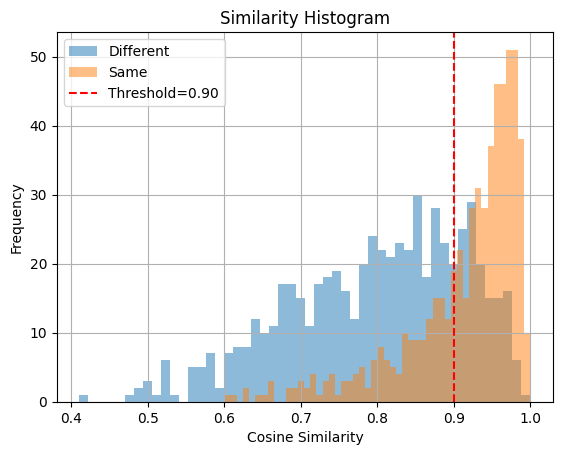

[Epoch 1] Validation Loss: 0.1813
Validation loss improved. Saving model...


Epoch 2/20: 100%|█████████████████████████████| 600/600 [01:08<00:00,  8.74it/s]


[Epoch 2] Train Loss: 0.1879

Validation Results:
Best Threshold: 0.92
Accuracy: 0.6617
F1 Score: 0.6762
ROC AUC: 0.7286
Confusion Matrix:
 [[370 240]
 [166 424]]


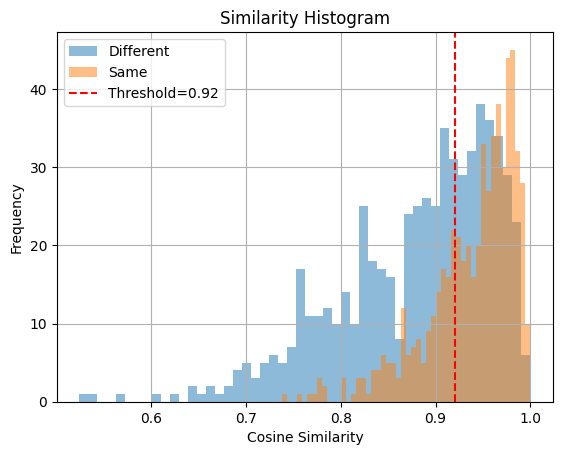

[Epoch 2] Validation Loss: 0.2233
No improvement for 1 epoch(s).


Epoch 3/20: 100%|█████████████████████████████| 600/600 [01:11<00:00,  8.43it/s]


[Epoch 3] Train Loss: 0.1765

Validation Results:
Best Threshold: 0.90
Accuracy: 0.7850
F1 Score: 0.7825
ROC AUC: 0.8571
Confusion Matrix:
 [[478 132]
 [126 464]]


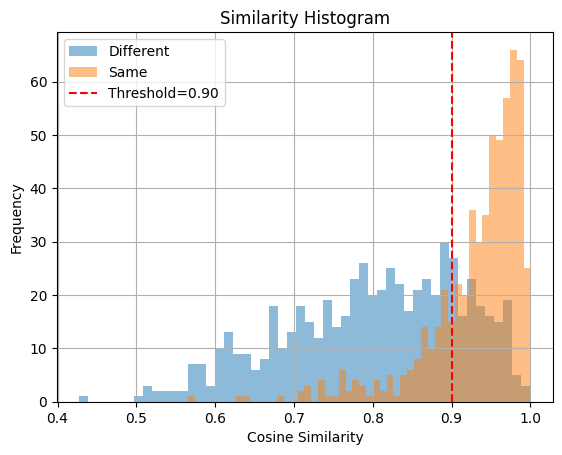

[Epoch 3] Validation Loss: 0.1662
Validation loss improved. Saving model...


Epoch 4/20: 100%|█████████████████████████████| 600/600 [01:10<00:00,  8.54it/s]


[Epoch 4] Train Loss: 0.1745

Validation Results:
Best Threshold: 0.89
Accuracy: 0.7700
F1 Score: 0.7738
ROC AUC: 0.8350
Confusion Matrix:
 [[452 158]
 [118 472]]


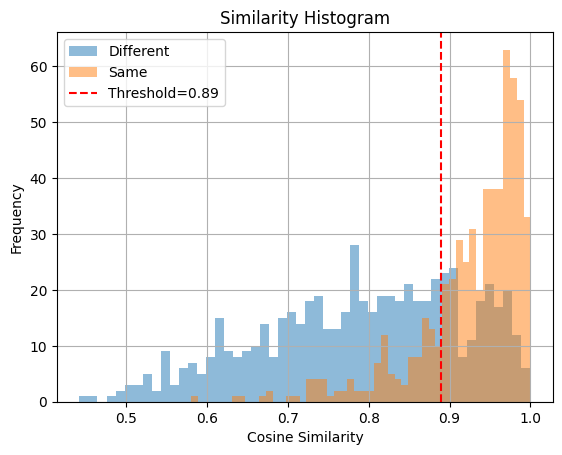

[Epoch 4] Validation Loss: 0.1711
No improvement for 1 epoch(s).


Epoch 5/20: 100%|█████████████████████████████| 600/600 [01:09<00:00,  8.61it/s]


[Epoch 5] Train Loss: 0.1718

Validation Results:
Best Threshold: 0.85
Accuracy: 0.7892
F1 Score: 0.8058
ROC AUC: 0.8661
Confusion Matrix:
 [[422 188]
 [ 65 525]]


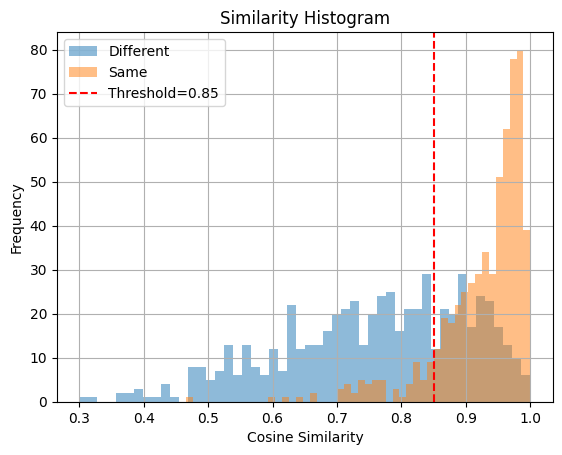

[Epoch 5] Validation Loss: 0.1561
Validation loss improved. Saving model...


Epoch 6/20: 100%|█████████████████████████████| 600/600 [01:10<00:00,  8.45it/s]


[Epoch 6] Train Loss: 0.1671

Validation Results:
Best Threshold: 0.89
Accuracy: 0.7050
F1 Score: 0.7030
ROC AUC: 0.7657
Confusion Matrix:
 [[427 183]
 [171 419]]


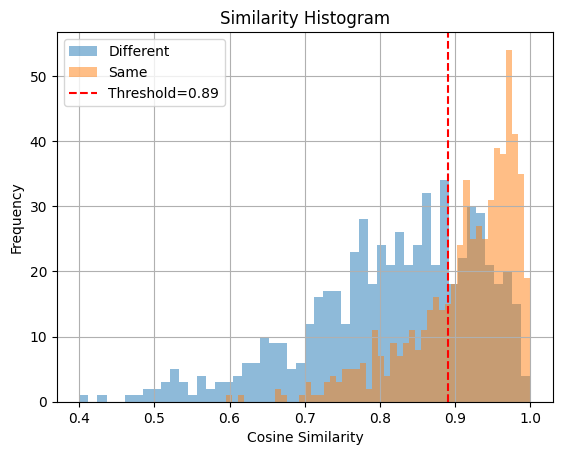

[Epoch 6] Validation Loss: 0.1987
No improvement for 1 epoch(s).


Epoch 7/20: 100%|█████████████████████████████| 600/600 [01:10<00:00,  8.55it/s]


[Epoch 7] Train Loss: 0.1665

Validation Results:
Best Threshold: 0.84
Accuracy: 0.7692
F1 Score: 0.7874
ROC AUC: 0.8489
Confusion Matrix:
 [[410 200]
 [ 77 513]]


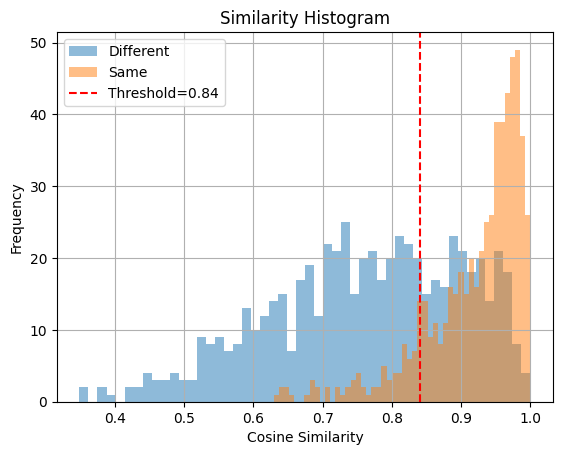

[Epoch 7] Validation Loss: 0.1632
No improvement for 2 epoch(s).


Epoch 8/20: 100%|█████████████████████████████| 600/600 [01:11<00:00,  8.36it/s]


[Epoch 8] Train Loss: 0.1631

Validation Results:
Best Threshold: 0.92
Accuracy: 0.7800
F1 Score: 0.7643
ROC AUC: 0.8667
Confusion Matrix:
 [[508 102]
 [162 428]]


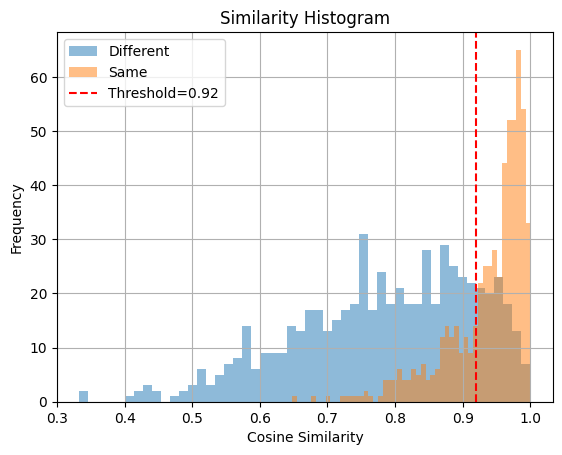

[Epoch 8] Validation Loss: 0.1581
No improvement for 3 epoch(s).


Epoch 9/20: 100%|█████████████████████████████| 600/600 [01:10<00:00,  8.50it/s]


[Epoch 9] Train Loss: 0.1608

Validation Results:
Best Threshold: 0.87
Accuracy: 0.7517
F1 Score: 0.7608
ROC AUC: 0.8293
Confusion Matrix:
 [[428 182]
 [116 474]]


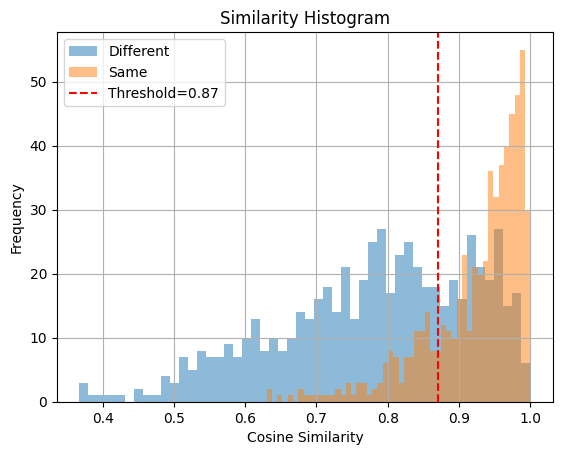

[Epoch 9] Validation Loss: 0.1717
No improvement for 4 epoch(s).


Epoch 10/20: 100%|████████████████████████████| 600/600 [01:11<00:00,  8.39it/s]


[Epoch 10] Train Loss: 0.1599

Validation Results:
Best Threshold: 0.87
Accuracy: 0.7950
F1 Score: 0.8032
ROC AUC: 0.8764
Confusion Matrix:
 [[452 158]
 [ 88 502]]


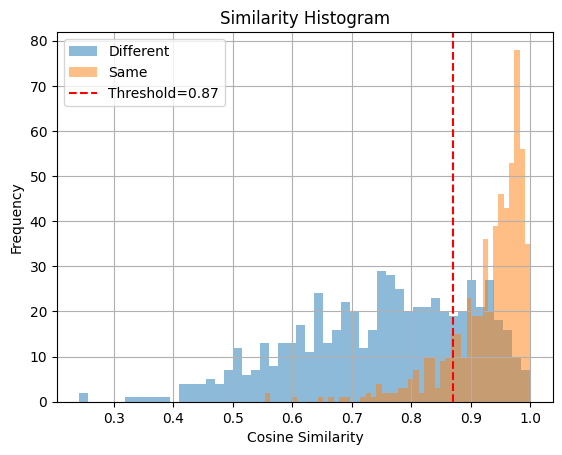

[Epoch 10] Validation Loss: 0.1508
Validation loss improved. Saving model...


Epoch 11/20: 100%|████████████████████████████| 600/600 [01:12<00:00,  8.30it/s]


[Epoch 11] Train Loss: 0.1591

Validation Results:
Best Threshold: 0.88
Accuracy: 0.7833
F1 Score: 0.7879
ROC AUC: 0.8598
Confusion Matrix:
 [[457 153]
 [107 483]]


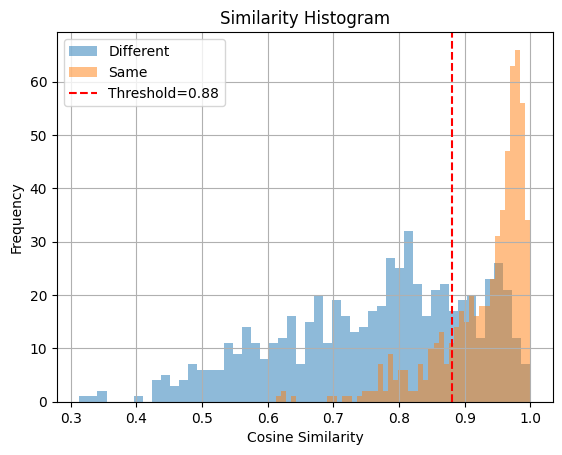

[Epoch 11] Validation Loss: 0.1578
No improvement for 1 epoch(s).


Epoch 12/20: 100%|████████████████████████████| 600/600 [01:11<00:00,  8.42it/s]


[Epoch 12] Train Loss: 0.1603

Validation Results:
Best Threshold: 0.88
Accuracy: 0.7850
F1 Score: 0.7956
ROC AUC: 0.8691
Confusion Matrix:
 [[440 170]
 [ 88 502]]


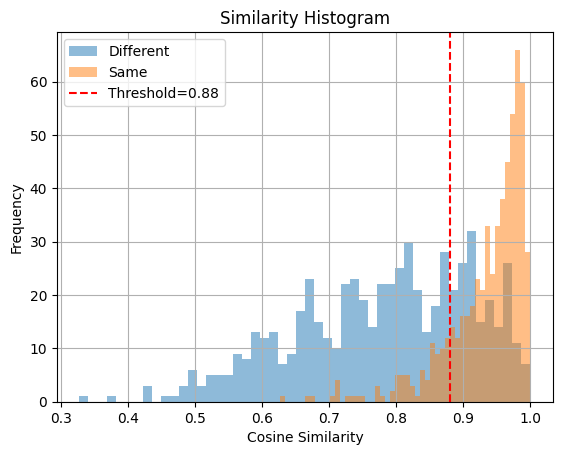

[Epoch 12] Validation Loss: 0.1568
No improvement for 2 epoch(s).


Epoch 13/20: 100%|████████████████████████████| 600/600 [01:11<00:00,  8.39it/s]


[Epoch 13] Train Loss: 0.1539

Validation Results:
Best Threshold: 0.90
Accuracy: 0.8100
F1 Score: 0.8081
ROC AUC: 0.8768
Confusion Matrix:
 [[492 118]
 [110 480]]


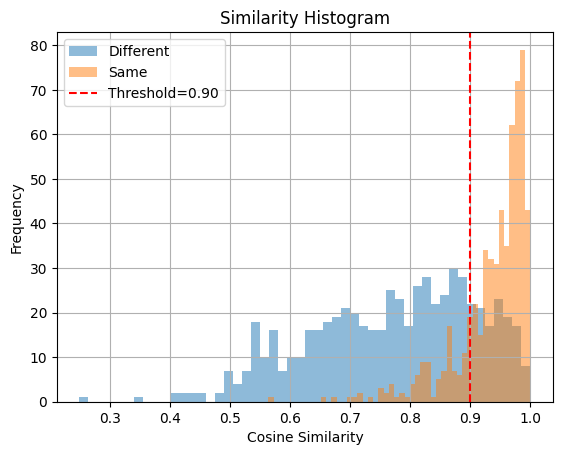

[Epoch 13] Validation Loss: 0.1515
No improvement for 3 epoch(s).


Epoch 14/20: 100%|████████████████████████████| 600/600 [01:11<00:00,  8.35it/s]


[Epoch 14] Train Loss: 0.1573

Validation Results:
Best Threshold: 0.87
Accuracy: 0.8008
F1 Score: 0.8099
ROC AUC: 0.8774
Confusion Matrix:
 [[452 158]
 [ 81 509]]


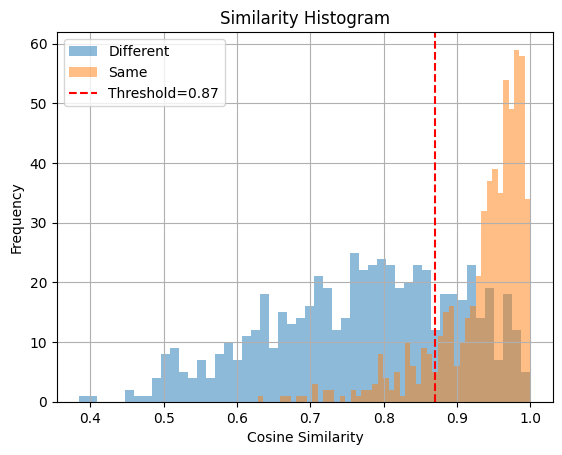

[Epoch 14] Validation Loss: 0.1519
No improvement for 4 epoch(s).


Epoch 15/20: 100%|████████████████████████████| 600/600 [01:10<00:00,  8.47it/s]


[Epoch 15] Train Loss: 0.1531

Validation Results:
Best Threshold: 0.88
Accuracy: 0.7583
F1 Score: 0.7623
ROC AUC: 0.8354
Confusion Matrix:
 [[445 165]
 [125 465]]


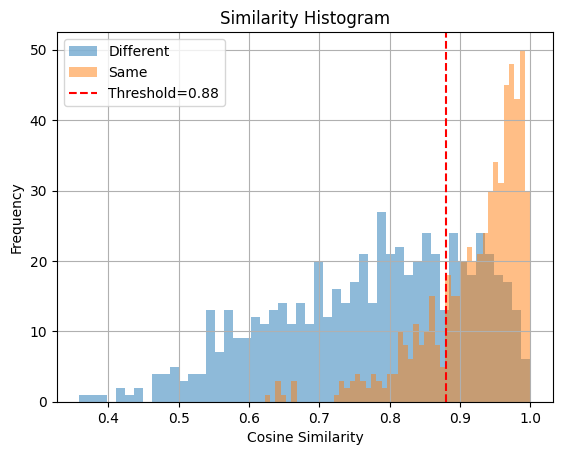

[Epoch 15] Validation Loss: 0.1687
No improvement for 5 epoch(s).
Early stopping activated after 15 epochs.


In [5]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Detektory twarzy
try:
    from facenet_pytorch import MTCNN
    mtcnn_detector = MTCNN(keep_all=True, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
except ImportError:
    mtcnn_detector = None
try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Face detection methods
# =========================

# Haar Cascade
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# MTCNN
def detect_face_mtcnn(image):
    if mtcnn_detector is None:
        raise RuntimeError("facenet-pytorch is not installed!")
    boxes, _ = mtcnn_detector.detect(image)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0].astype(int)
        face = image[y1:y2, x1:x2]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# RetinaFace
def detect_face_retinaface(image):
    if RetinaFace is None:
        raise RuntimeError("retinaface package is not installed!")
    faces = RetinaFace.extract_faces(image, align=True)
    if faces and len(faces) > 0:
        face = faces[0]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class with detector selection
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, detector='haar'):
        self.pairs = []
        self.transform = transform
        self.detector = detector
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def detect(self, image):
        if self.detector == 'haar':
            return detect_face_haar(image)
        elif self.detector == 'mtcnn':
            return detect_face_mtcnn(image)
        elif self.detector == 'retinaface':
            return detect_face_retinaface(image)
        else:
            raise ValueError(f"Unknown detector: {self.detector}")

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = self.detect(img0)
        img1 = self.detect(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='facenet', dropout_prob=0.3):  
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),  
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        if hasattr(self.feature_extractor, 'eval'):
            # used in eval mode
            with torch.no_grad():
                x = self.feature_extractor(x)
        else:
            x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Early Stopping
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=3, min_delta=1e-4):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f}")

        # Ewaluacja na zbiorze walidacyjnym (wyświetla histogram i metryki)
        evaluate_with_histogram(model, val_loader)

        # early stopping
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                out1, out2 = model(img1, img2)
                val_loss = criterion(out1, out2, label)
                val_loss_total += val_loss.item()
        avg_val_loss = val_loss_total / len(val_loader)
        print(f"[Epoch {epoch+1}] Validation Loss: {avg_val_loss:.4f}")

        # Sprawdzenie early stopping
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print("Validation loss improved. Saving model...")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping activated after {epoch+1} epochs.")
            break

    # najlepszy model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'

    # Wybierz detektor: 'haar', 'mtcnn', 'retinaface'
    chosen_detector = 'haar'

    # Przygotowanie datasetu
    dataset = SiameseFaceDataset(base_path, transform=transform, detector=chosen_detector)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    # backbone: 'resnet', 'mobilenet', 'facenet'
    model = SiameseNetwork(backbone='facenet', dropout_prob=0.3).to(device)

    # Kryterium i optymalizator
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Trening z early stopping
    train(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5)



In [ ]:
################################################ mtcnn + resnet
################################################ + contrastive loss + cosine sim + regularisation + early stopping
################################################ => UNDONE -> GPU

In [ ]:
import os
import re
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Detektory twarzy
try:
    from facenet_pytorch import MTCNN
    mtcnn_detector = MTCNN(keep_all=True, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
except ImportError:
    mtcnn_detector = None
try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

# =========================
# Device Setup
# =========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# Face detection methods
# =========================

# Haar Cascade
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

def detect_face_haar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# MTCNN
def detect_face_mtcnn(image):
    if mtcnn_detector is None:
        raise RuntimeError("facenet-pytorch is not installed!")
    boxes, _ = mtcnn_detector.detect(image)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0].astype(int)
        face = image[y1:y2, x1:x2]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# RetinaFace
def detect_face_retinaface(image):
    if RetinaFace is None:
        raise RuntimeError("retinaface package is not installed!")
    faces = RetinaFace.extract_faces(image, align=True)
    if faces and len(faces) > 0:
        face = faces[0]
        return cv2.resize(face, (160, 160))
    return np.zeros((160, 160, 3), dtype=np.uint8)

# =========================
# Dataset Class with detector selection
# =========================
class SiameseFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, detector='mtcnn'):
        self.pairs = []
        self.transform = transform
        self.detector = detector
        for root, _, _ in os.walk(root_dir):
            match = re.search(r'label_(\d+)', root)
            if not match: continue
            label = int(match.group(1))
            im0 = next((f for f in os.listdir(root) if f.startswith("im_0_")), None)
            im1 = next((f for f in os.listdir(root) if f.startswith("im_1_")), None)
            if im0 and im1:
                self.pairs.append((os.path.join(root, im0), os.path.join(root, im1), label))

    def __len__(self): return len(self.pairs)

    def detect(self, image):
        if self.detector == 'haar':
            return detect_face_haar(image)
        elif self.detector == 'mtcnn':
            return detect_face_mtcnn(image)
        elif self.detector == 'retinaface':
            return detect_face_retinaface(image)
        else:
            raise ValueError(f"Unknown detector: {self.detector}")

    def __getitem__(self, idx):
        path0, path1, label = self.pairs[idx]
        img0 = cv2.cvtColor(cv2.imread(path0), cv2.COLOR_BGR2RGB)
        img1 = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
        img0 = self.detect(img0)
        img1 = self.detect(img1)
        if self.transform:
            img0 = self.transform(image=img0)['image']
            img1 = self.transform(image=img1)['image']
        return img0.to(torch.float32), img1.to(torch.float32), torch.tensor(label, dtype=torch.float32)

# =========================
# Data Transforms
# =========================
transform = A.Compose([
    A.Resize(160, 160),
    A.Normalize(),
    ToTensorV2()
])

# =========================
# Siamese Network with backbone option
# =========================
class SiameseNetwork(nn.Module):
    def __init__(self, backbone='resnet', dropout_prob=0.3):  
        super().__init__()
        if backbone == 'resnet':
            base = models.resnet18(pretrained=True)
            self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
            self.embedding_size = base.fc.in_features
        elif backbone == 'mobilenet':
            base = models.mobilenet_v2(pretrained=True)
            self.feature_extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d(1))
            self.embedding_size = base.last_channel
        elif backbone == 'facenet':
            from facenet_pytorch import InceptionResnetV1
            self.feature_extractor = InceptionResnetV1(pretrained='vggface2').eval()
            self.embedding_size = 512
        else:
            raise ValueError("Backbone must be 'resnet', 'mobilenet', or 'facenet'")

        self.fc = nn.Sequential(
            nn.Linear(self.embedding_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),  
            nn.Linear(256, 128)
        )

    def forward_once(self, x):
        if hasattr(self.feature_extractor, 'eval'):
            # used in eval mode
            with torch.no_grad():
                x = self.feature_extractor(x)
        else:
            x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return F.normalize(self.fc(x), p=2, dim=1)

    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

# =========================
# Contrastive Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()

# =========================
# Train Loop with Early Stopping
# =========================
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=3, min_delta=1e-4):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for img1, img2, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f}")

        # Ewaluacja na zbiorze walidacyjnym (wyświetla histogram i metryki)
        evaluate_with_histogram(model, val_loader)

        # early stopping
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for img1, img2, label in val_loader:
                img1, img2, label = img1.to(device), img2.to(device), label.to(device)
                out1, out2 = model(img1, img2)
                val_loss = criterion(out1, out2, label)
                val_loss_total += val_loss.item()
        avg_val_loss = val_loss_total / len(val_loader)
        print(f"[Epoch {epoch+1}] Validation Loss: {avg_val_loss:.4f}")

        # Sprawdzenie early stopping
        if best_val_loss - avg_val_loss > min_delta:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print("Validation loss improved. Saving model...")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"Early stopping activated after {epoch+1} epochs.")
            break

    # najlepszy model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model


# =========================
# Evaluation with Histogram
# =========================
def evaluate_with_histogram(model, loader):
    model.eval()
    y_true, sims = [], []
    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            sim = F.cosine_similarity(out1, out2).item()
            sims.append(sim)
            y_true.append(int(label.item()))

    thresholds = np.arange(0, 1.01, 0.01)
    best_acc, best_f1, best_thresh = 0, 0, 0
    for t in thresholds:
        y_pred = [1 if s > t else 0 for s in sims]
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        if acc > best_acc:
            best_acc, best_f1, best_thresh = acc, f1, t

    print(f"\nValidation Results:")
    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Accuracy: {best_acc:.4f}")
    print(f"F1 Score: {best_f1:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, sims):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, [1 if s > best_thresh else 0 for s in sims]))

    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 0], bins=50, alpha=0.5, label="Different")
    plt.hist([sims[i] for i in range(len(sims)) if y_true[i] == 1], bins=50, alpha=0.5, label="Same")
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.2f}')
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Similarity Histogram")
    plt.grid(True)
    plt.show()

# =========================
# Run
# =========================
if __name__ == "__main__":
    base_path = './AdvLFW/images'

    # Wybierz detektor: 'haar', 'mtcnn', 'retinaface'
    chosen_detector = 'retinaface'

    # Przygotowanie datasetu
    dataset = SiameseFaceDataset(base_path, transform=transform, detector=chosen_detector)
    train_len = int(0.8 * len(dataset))
    val_len = len(dataset) - train_len
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

    # backbone: 'resnet', 'mobilenet', 'facenet'
    model = SiameseNetwork(backbone='resnet', dropout_prob=0.3).to(device)

    # Kryterium i optymalizator
    criterion = ContrastiveLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Trening z early stopping
    train(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5)

